# Notebook 08: Regional Video Game Market Preferences

## Objective

This notebook examines how video game sales patterns differ across North America, Europe, and Japan.

Previous analyses primarily evaluated overall performance using global sales, game characteristics, and predictive modeling. However, global totals can hide important differences between regional markets. A genre that performs strongly in one region may have limited popularity in another.

This analysis compares genre-level sales across the three main regional markets in the dataset:

- North America
- Europe
- Japan

Both total regional sales and proportional sales distributions will be examined. Using proportions is important because the regional markets differ substantially in total sales volume.

The `other_sales` category is excluded from the primary regional comparison because it combines multiple geographic markets rather than representing a single region.

The results will help identify genres with broad international appeal and genres whose commercial performance is concentrated in a particular region.

## Research Question

**How do video game genre preferences differ across North America, Europe, and Japan?**

This analysis will answer the following supporting questions:

1. Which genres generate the most sales in each region?
2. What percentage of each region's total sales is generated by each genre?
3. Which genres have similar popularity across regions?
4. Which genres are particularly concentrated in one regional market?

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# Visualization settings
sns.set_theme(style="whitegrid")

In [2]:
candidate_paths = [
    Path("../../data/processed/video_game_sales_cleaned.csv"),
    Path("../data/processed/video_game_sales_cleaned.csv"),
    Path("data/processed/video_game_sales_cleaned.csv"),
]

data_path = next((path for path in candidate_paths if path.exists()), None)

if data_path is None:
    raise FileNotFoundError(
        "Could not find video_game_sales_cleaned.csv. "
        "Update candidate_paths to match the notebook's location."
    )

df = pd.read_csv(data_path)

print(f"Loaded: {data_path.resolve()}")
print(f"Dataset shape: {df.shape}")
df.head()

Loaded: C:\Users\tyler\OneDrive\Desktop\26projects\data_an\data-analysis-on-the-videogame-industry\data\processed\video_game_sales_cleaned.csv
Dataset shape: (16287, 19)


,name,platform,year,genre,publisher,na_sales,eu_sales,jp_sales,other_sales,global_sales,regional_sales_total,decade,sales_tier,is_high_seller,na_sales_share,eu_sales_share,jp_sales_share,other_sales_share,dominant_region
0,Wii Sports,Wii,2006,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74,82.74,2000s,blockbuster,1,0.50,0.35,0.05,0.10,North America
1,Super Mario Bros.,NES,1985,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,40.24,1980s,blockbuster,1,0.72,0.09,0.17,0.02,North America
2,Mario Kart Wii,Wii,2008,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82,35.83,2000s,blockbuster,1,0.44,0.36,0.11,0.09,North America
3,Wii Sports Resort,Wii,2009,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00,33.00,2000s,blockbuster,1,0.48,0.33,0.10,0.09,North America
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,31.38,1990s,blockbuster,1,0.36,0.28,0.33,0.03,North America


In [3]:
# Columns required for the regional genre analysis
regional_columns = [
    "genre",
    "na_sales",
    "eu_sales",
    "jp_sales"
]

regional_df = df[regional_columns].copy()

regional_df.head()

,genre,na_sales,eu_sales,jp_sales
0,Sports,41.49,29.02,3.77
1,Platform,29.08,3.58,6.81
2,Racing,15.85,12.88,3.79
3,Sports,15.75,11.01,3.28
4,Role-Playing,11.27,8.89,10.22


In [4]:
# Confirm that regional sales columns contain valid numeric values
regional_df[["na_sales", "eu_sales", "jp_sales"]].describe()

,na_sales,eu_sales,jp_sales
count,"16,287.00","16,287.00","16,287.00"
mean,0.27,0.15,0.08
std,0.82,0.51,0.31
min,0.00,0.00,0.00
25%,0.00,0.00,0.00
50%,0.08,0.02,0.00
75%,0.24,0.11,0.04
max,41.49,29.02,10.22


In [5]:
# Regional sales should not contain negative values
negative_sales = (
    regional_df[["na_sales", "eu_sales", "jp_sales"]] < 0
).sum()

negative_sales

na_sales    0
eu_sales    0
jp_sales    0
dtype: int64

## 1. Total Sales by Genre and Region

The first stage of the analysis aggregates total sales for each genre within North America, Europe, and Japan.

These totals show the commercial size of each genre in each region. However, because the three regional markets have different total sales volumes, market-share percentages will also be calculated later for a more comparable measure of regional preference.

In [6]:
# Aggregate regional sales by genre
genre_regional_sales = (
    regional_df
    .groupby("genre", as_index=False)[
        ["na_sales", "eu_sales", "jp_sales"]
    ]
    .sum()
)

# Add combined sales across the three selected regions
genre_regional_sales["combined_regional_sales"] = (
    genre_regional_sales["na_sales"]
    + genre_regional_sales["eu_sales"]
    + genre_regional_sales["jp_sales"]
)

# Sort genres by combined regional sales
genre_regional_sales = genre_regional_sales.sort_values(
    "combined_regional_sales",
    ascending=False
).reset_index(drop=True)

genre_regional_sales

,genre,na_sales,eu_sales,jp_sales,combined_regional_sales
0,Action,861.77,516.48,158.64,"1,536.89"
1,Sports,670.09,371.34,134.76,"1,176.19"
2,Shooter,575.16,310.45,38.18,923.79
3,Role-Playing,326.50,187.57,350.25,864.32
4,Platform,445.99,200.65,130.65,777.29
5,Misc,396.92,211.77,106.67,715.36
6,Racing,356.93,236.31,56.61,649.85
7,Fighting,220.74,100.00,87.15,407.89
8,Simulation,181.51,113.02,63.54,358.07
9,Puzzle,122.01,50.52,56.68,229.21


## 2. Regional Sales Summary

To make the results easier to read, the regional sales columns are renamed using their full market names.

The table is ordered by combined sales across North America, Europe, and Japan.

In [7]:
# Create a presentation-ready version of the regional sales table
regional_sales_summary = genre_regional_sales.rename(
    columns={
        "genre": "Genre",
        "na_sales": "North America",
        "eu_sales": "Europe",
        "jp_sales": "Japan",
        "combined_regional_sales": "Combined Sales"
    }
)

regional_sales_summary

,Genre,North America,Europe,Japan,Combined Sales
0,Action,861.77,516.48,158.64,"1,536.89"
1,Sports,670.09,371.34,134.76,"1,176.19"
2,Shooter,575.16,310.45,38.18,923.79
3,Role-Playing,326.50,187.57,350.25,864.32
4,Platform,445.99,200.65,130.65,777.29
5,Misc,396.92,211.77,106.67,715.36
6,Racing,356.93,236.31,56.61,649.85
7,Fighting,220.74,100.00,87.15,407.89
8,Simulation,181.51,113.02,63.54,358.07
9,Puzzle,122.01,50.52,56.68,229.21


## 3. Total Genre Sales Across Regions

A grouped bar chart is used to compare total genre sales across North America, Europe, and Japan.

This visualization shows the absolute commercial performance of each genre in the three markets.

In [8]:
# Prepare the data in long format for visualization
regional_sales_long = genre_regional_sales.melt(
    id_vars="genre",
    value_vars=["na_sales", "eu_sales", "jp_sales"],
    var_name="region",
    value_name="sales"
)

# Replace abbreviated region names with readable labels
region_labels = {
    "na_sales": "North America",
    "eu_sales": "Europe",
    "jp_sales": "Japan"
}

regional_sales_long["region"] = (
    regional_sales_long["region"].map(region_labels)
)

regional_sales_long.head()

,genre,region,sales
0,Action,North America,861.77
1,Sports,North America,670.09
2,Shooter,North America,575.16
3,Role-Playing,North America,326.50
4,Platform,North America,445.99


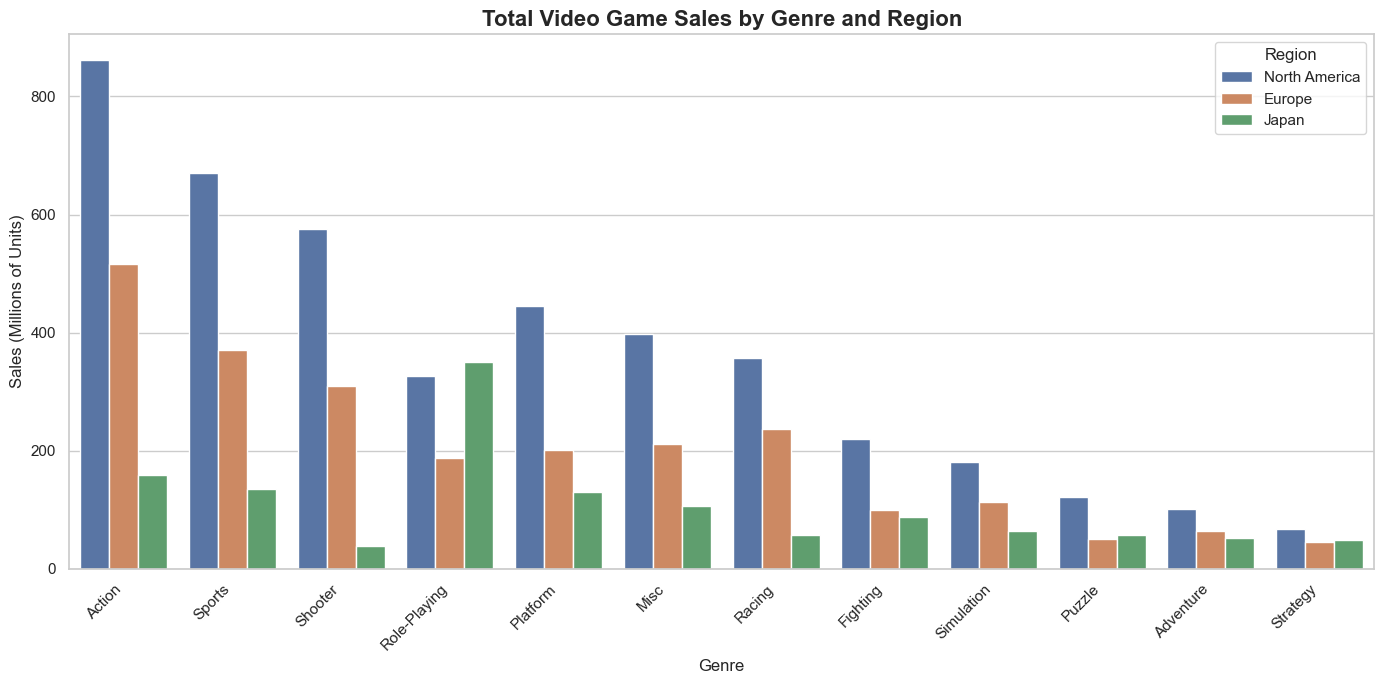

In [9]:
# Preserve the genre order from the combined regional sales ranking
genre_order = genre_regional_sales["genre"].tolist()

plt.figure(figsize=(14, 7))

sns.barplot(
    data=regional_sales_long,
    x="genre",
    y="sales",
    hue="region",
    order=genre_order
)

plt.title(
    "Total Video Game Sales by Genre and Region",
    fontsize=16,
    fontweight="bold"
)
plt.xlabel("Genre")
plt.ylabel("Sales (Millions of Units)")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Region")
plt.tight_layout()
plt.show()

## 4. Genre Rankings by Region

Each genre is ranked separately within North America, Europe, and Japan.

A rank of 1 represents the genre with the highest total sales in that region.

In [10]:
# Create a genre ranking table for each region
regional_rankings = genre_regional_sales[
    ["genre", "na_sales", "eu_sales", "jp_sales"]
].copy()

regional_rankings["na_rank"] = (
    regional_rankings["na_sales"]
    .rank(method="min", ascending=False)
    .astype(int)
)

regional_rankings["eu_rank"] = (
    regional_rankings["eu_sales"]
    .rank(method="min", ascending=False)
    .astype(int)
)

regional_rankings["jp_rank"] = (
    regional_rankings["jp_sales"]
    .rank(method="min", ascending=False)
    .astype(int)
)

regional_rankings = regional_rankings[
    [
        "genre",
        "na_sales",
        "na_rank",
        "eu_sales",
        "eu_rank",
        "jp_sales",
        "jp_rank"
    ]
]

regional_rankings = regional_rankings.sort_values(
    "na_rank"
).reset_index(drop=True)

regional_rankings

,genre,na_sales,na_rank,eu_sales,eu_rank,jp_sales,jp_rank
0,Action,861.77,1,516.48,1,158.64,2
1,Sports,670.09,2,371.34,2,134.76,3
2,Shooter,575.16,3,310.45,3,38.18,12
3,Platform,445.99,4,200.65,6,130.65,4
4,Misc,396.92,5,211.77,5,106.67,5
5,Racing,356.93,6,236.31,4,56.61,9
6,Role-Playing,326.50,7,187.57,7,350.25,1
7,Fighting,220.74,8,100.00,9,87.15,6
8,Simulation,181.51,9,113.02,8,63.54,7
9,Puzzle,122.01,10,50.52,11,56.68,8


In [11]:
regional_rankings_display = regional_rankings.rename(
    columns={
        "genre": "Genre",
        "na_sales": "North America Sales",
        "na_rank": "North America Rank",
        "eu_sales": "Europe Sales",
        "eu_rank": "Europe Rank",
        "jp_sales": "Japan Sales",
        "jp_rank": "Japan Rank"
    }
)

regional_rankings_display

,Genre,North America Sales,North America Rank,Europe Sales,Europe Rank,Japan Sales,Japan Rank
0,Action,861.77,1,516.48,1,158.64,2
1,Sports,670.09,2,371.34,2,134.76,3
2,Shooter,575.16,3,310.45,3,38.18,12
3,Platform,445.99,4,200.65,6,130.65,4
4,Misc,396.92,5,211.77,5,106.67,5
5,Racing,356.93,6,236.31,4,56.61,9
6,Role-Playing,326.50,7,187.57,7,350.25,1
7,Fighting,220.74,8,100.00,9,87.15,6
8,Simulation,181.51,9,113.02,8,63.54,7
9,Puzzle,122.01,10,50.52,11,56.68,8


## 5. Top Five Genres in Each Region

The following tables display the five highest-selling genres separately for North America, Europe, and Japan.

In [12]:
# Top five genres in North America
top_na_genres = (
    genre_regional_sales[
        ["genre", "na_sales"]
    ]
    .sort_values("na_sales", ascending=False)
    .head(5)
    .reset_index(drop=True)
)

top_na_genres.index = top_na_genres.index + 1
top_na_genres

,genre,na_sales
1,Action,861.77
2,Sports,670.09
3,Shooter,575.16
4,Platform,445.99
5,Misc,396.92


In [13]:
# Top five genres in Europe
top_eu_genres = (
    genre_regional_sales[
        ["genre", "eu_sales"]
    ]
    .sort_values("eu_sales", ascending=False)
    .head(5)
    .reset_index(drop=True)
)

top_eu_genres.index = top_eu_genres.index + 1
top_eu_genres

,genre,eu_sales
1,Action,516.48
2,Sports,371.34
3,Shooter,310.45
4,Racing,236.31
5,Misc,211.77


In [14]:
# Top five genres in Japan
top_jp_genres = (
    genre_regional_sales[
        ["genre", "jp_sales"]
    ]
    .sort_values("jp_sales", ascending=False)
    .head(5)
    .reset_index(drop=True)
)

top_jp_genres.index = top_jp_genres.index + 1
top_jp_genres

,genre,jp_sales
1,Role-Playing,350.25
2,Action,158.64
3,Sports,134.76
4,Platform,130.65
5,Misc,106.67


## 6. Top-Selling Genres by Region

Separate charts make it easier to see which genres lead each regional market without differences in regional market size affecting the visual comparison.

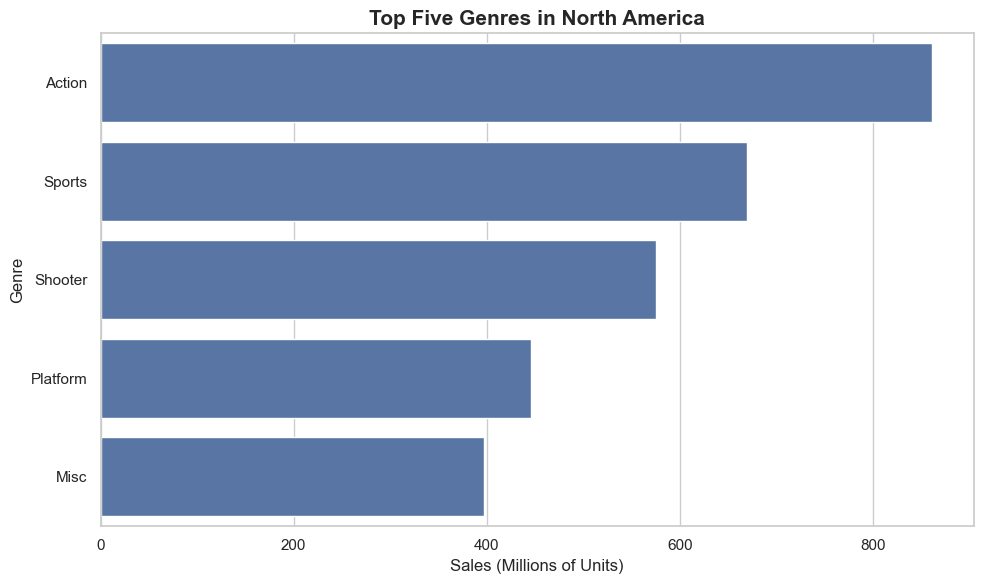

In [15]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_na_genres,
    x="na_sales",
    y="genre"
)

plt.title(
    "Top Five Genres in North America",
    fontsize=15,
    fontweight="bold"
)
plt.xlabel("Sales (Millions of Units)")
plt.ylabel("Genre")
plt.tight_layout()
plt.show()

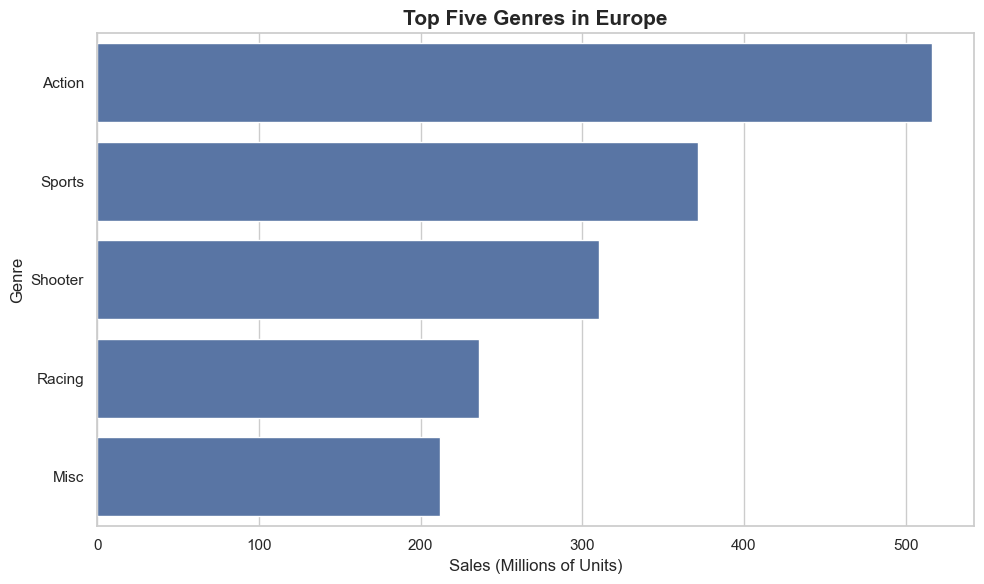

In [16]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_eu_genres,
    x="eu_sales",
    y="genre"
)

plt.title(
    "Top Five Genres in Europe",
    fontsize=15,
    fontweight="bold"
)
plt.xlabel("Sales (Millions of Units)")
plt.ylabel("Genre")
plt.tight_layout()
plt.show()

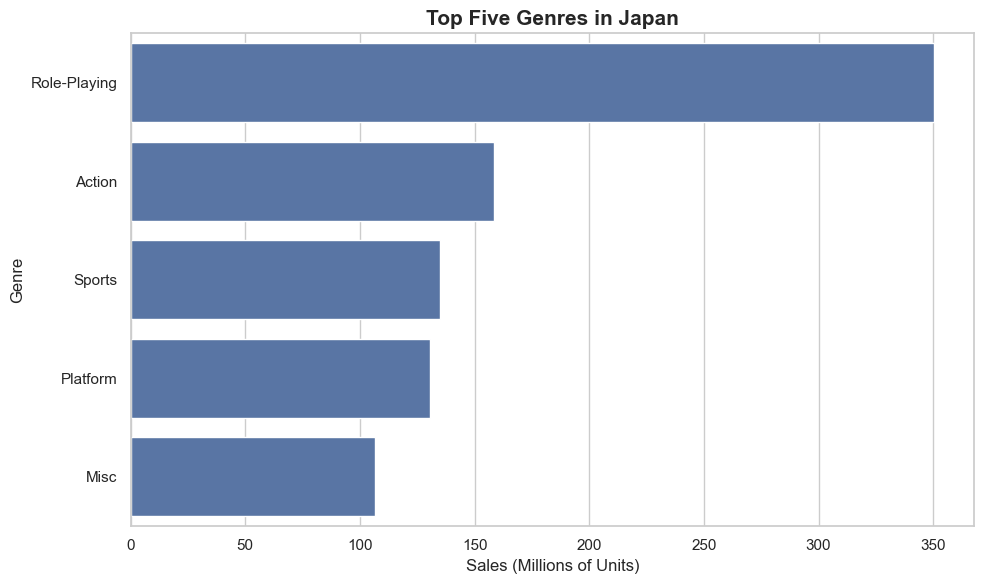

In [17]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_jp_genres,
    x="jp_sales",
    y="genre"
)

plt.title(
    "Top Five Genres in Japan",
    fontsize=15,
    fontweight="bold"
)
plt.xlabel("Sales (Millions of Units)")
plt.ylabel("Genre")
plt.tight_layout()
plt.show()

## 7. Regional Market Size

Before comparing genre preferences, the total sales volume of each regional market is calculated.

This confirms whether the three regions have similar or different overall market sizes.

In [18]:
# Calculate total video game sales in each region
regional_market_totals = regional_df[
    ["na_sales", "eu_sales", "jp_sales"]
].sum()

regional_market_totals = regional_market_totals.rename(
    {
        "na_sales": "North America",
        "eu_sales": "Europe",
        "jp_sales": "Japan"
    }
)

regional_market_totals

North America   4,327.38
Europe          2,406.69
Japan           1,284.22
dtype: float64

In [19]:
# Convert the totals into a DataFrame
regional_market_totals_df = (
    regional_market_totals
    .reset_index()
)

regional_market_totals_df.columns = [
    "Region",
    "Total Sales"
]

regional_market_totals_df

,Region,Total Sales
0,North America,"4,327.38"
1,Europe,"2,406.69"
2,Japan,"1,284.22"


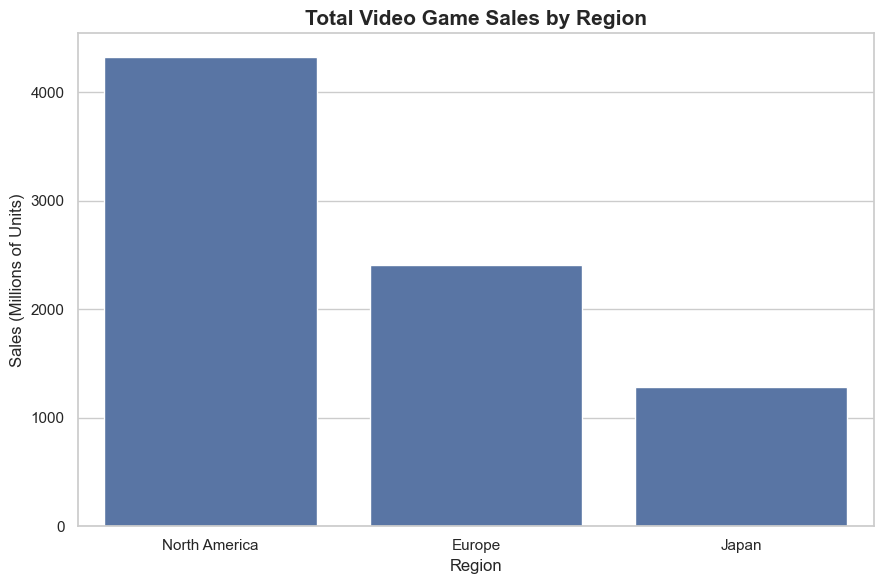

In [20]:
plt.figure(figsize=(9, 6))

sns.barplot(
    data=regional_market_totals_df,
    x="Region",
    y="Total Sales"
)

plt.title(
    "Total Video Game Sales by Region",
    fontsize=15,
    fontweight="bold"
)
plt.xlabel("Region")
plt.ylabel("Sales (Millions of Units)")
plt.tight_layout()
plt.show()

## 8. Genre Market Share Within Each Region

Raw sales totals are affected by the overall size of each regional market.

To create a fairer comparison, each genre's sales are converted into a percentage of total sales within its region.

For example, a North American market share of 20% means that the genre accounts for 20% of all North American sales represented in the dataset.

In [21]:
# Create a copy for regional market-share calculations
genre_market_share = genre_regional_sales[
    ["genre", "na_sales", "eu_sales", "jp_sales"]
].copy()

# Calculate each genre's percentage of total sales in each region
genre_market_share["na_share_pct"] = (
    genre_market_share["na_sales"]
    / genre_market_share["na_sales"].sum()
    * 100
)

genre_market_share["eu_share_pct"] = (
    genre_market_share["eu_sales"]
    / genre_market_share["eu_sales"].sum()
    * 100
)

genre_market_share["jp_share_pct"] = (
    genre_market_share["jp_sales"]
    / genre_market_share["jp_sales"].sum()
    * 100
)

genre_market_share = genre_market_share[
    [
        "genre",
        "na_share_pct",
        "eu_share_pct",
        "jp_share_pct"
    ]
]

genre_market_share

,genre,na_share_pct,eu_share_pct,jp_share_pct
0,Action,19.91,21.46,12.35
1,Sports,15.48,15.43,10.49
2,Shooter,13.29,12.90,2.97
3,Role-Playing,7.54,7.79,27.27
4,Platform,10.31,8.34,10.17
5,Misc,9.17,8.80,8.31
6,Racing,8.25,9.82,4.41
7,Fighting,5.10,4.16,6.79
8,Simulation,4.19,4.70,4.95
9,Puzzle,2.82,2.10,4.41


In [22]:
genre_market_share_display = genre_market_share.rename(
    columns={
        "genre": "Genre",
        "na_share_pct": "North America Share (%)",
        "eu_share_pct": "Europe Share (%)",
        "jp_share_pct": "Japan Share (%)"
    }
)

genre_market_share_display

,Genre,North America Share (%),Europe Share (%),Japan Share (%)
0,Action,19.91,21.46,12.35
1,Sports,15.48,15.43,10.49
2,Shooter,13.29,12.90,2.97
3,Role-Playing,7.54,7.79,27.27
4,Platform,10.31,8.34,10.17
5,Misc,9.17,8.80,8.31
6,Racing,8.25,9.82,4.41
7,Fighting,5.10,4.16,6.79
8,Simulation,4.19,4.70,4.95
9,Puzzle,2.82,2.10,4.41


## 9. Validate Regional Market Shares

As a validation check, the genre market shares are summed within each region. Each regional distribution should total approximately 100%.


In [23]:
# Each regional market-share column should total approximately 100%
market_share_totals = genre_market_share[
    ["na_share_pct", "eu_share_pct", "jp_share_pct"]
].sum()

market_share_totals

na_share_pct   100.00
eu_share_pct   100.00
jp_share_pct   100.00
dtype: float64

## 10. Regional Genre Market-Share Comparison

The grouped bar chart compares the percentage of each regional market represented by each genre.

Unlike the earlier total-sales chart, this visualization controls for differences in overall regional market size.

In [24]:
# Convert regional market shares into long format
market_share_long = genre_market_share.melt(
    id_vars="genre",
    value_vars=[
        "na_share_pct",
        "eu_share_pct",
        "jp_share_pct"
    ],
    var_name="region",
    value_name="market_share_pct"
)

share_region_labels = {
    "na_share_pct": "North America",
    "eu_share_pct": "Europe",
    "jp_share_pct": "Japan"
}

market_share_long["region"] = (
    market_share_long["region"].map(share_region_labels)
)

market_share_long.head()

,genre,region,market_share_pct
0,Action,North America,19.91
1,Sports,North America,15.48
2,Shooter,North America,13.29
3,Role-Playing,North America,7.54
4,Platform,North America,10.31


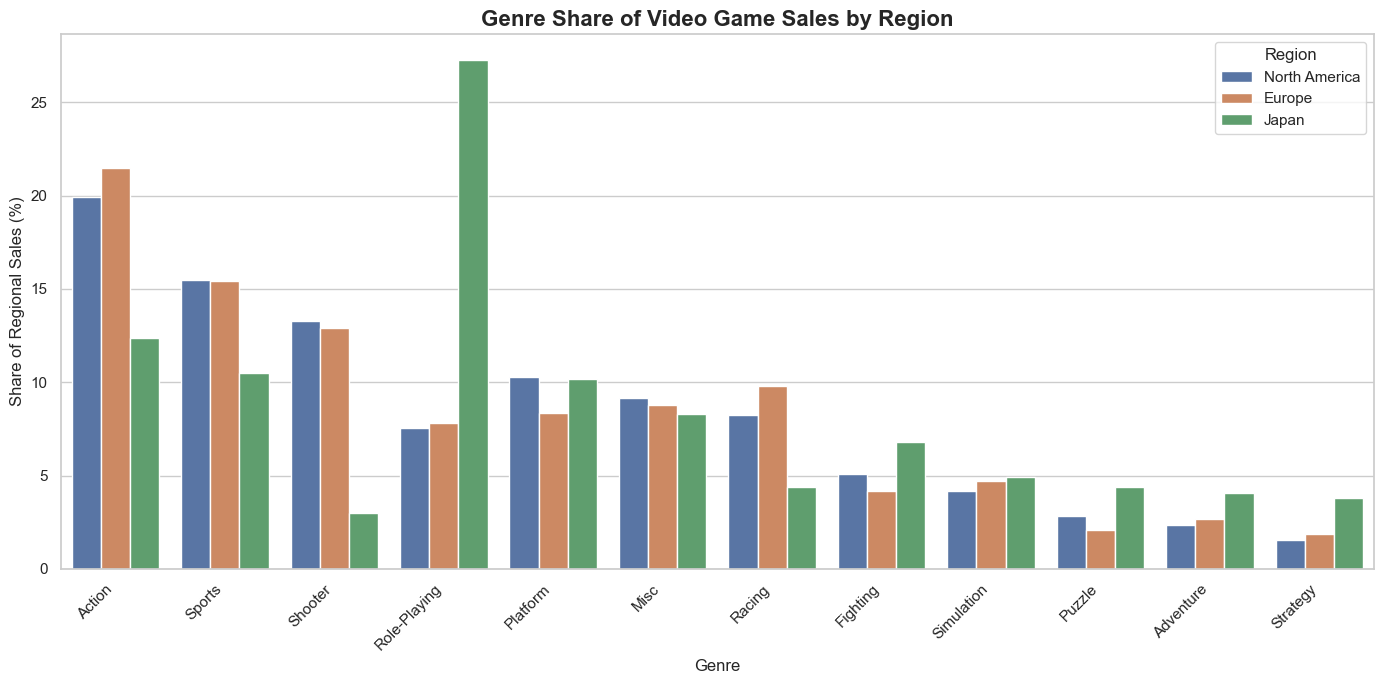

In [25]:
plt.figure(figsize=(14, 7))

sns.barplot(
    data=market_share_long,
    x="genre",
    y="market_share_pct",
    hue="region",
    order=genre_order
)

plt.title(
    "Genre Share of Video Game Sales by Region",
    fontsize=16,
    fontweight="bold"
)
plt.xlabel("Genre")
plt.ylabel("Share of Regional Sales (%)")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Region")
plt.tight_layout()
plt.show()

## 11. Regional Genre Preference Heatmap

A heatmap provides a compact comparison of genre market shares across the three regions.

Higher values indicate that a genre represents a larger percentage of total sales within that regional market.

In [26]:
# Reshape the market-share table for the heatmap
market_share_heatmap = (
    genre_market_share
    .set_index("genre")[
        ["na_share_pct", "eu_share_pct", "jp_share_pct"]
    ]
)

market_share_heatmap.columns = [
    "North America",
    "Europe",
    "Japan"
]

# Sort using the combined regional sales order
market_share_heatmap = market_share_heatmap.reindex(
    genre_order
)

market_share_heatmap

,North America,Europe,Japan
genre,,,
Action,19.91,21.46,12.35
Sports,15.48,15.43,10.49
Shooter,13.29,12.90,2.97
Role-Playing,7.54,7.79,27.27
Platform,10.31,8.34,10.17
Misc,9.17,8.80,8.31
Racing,8.25,9.82,4.41
Fighting,5.10,4.16,6.79
Simulation,4.19,4.70,4.95


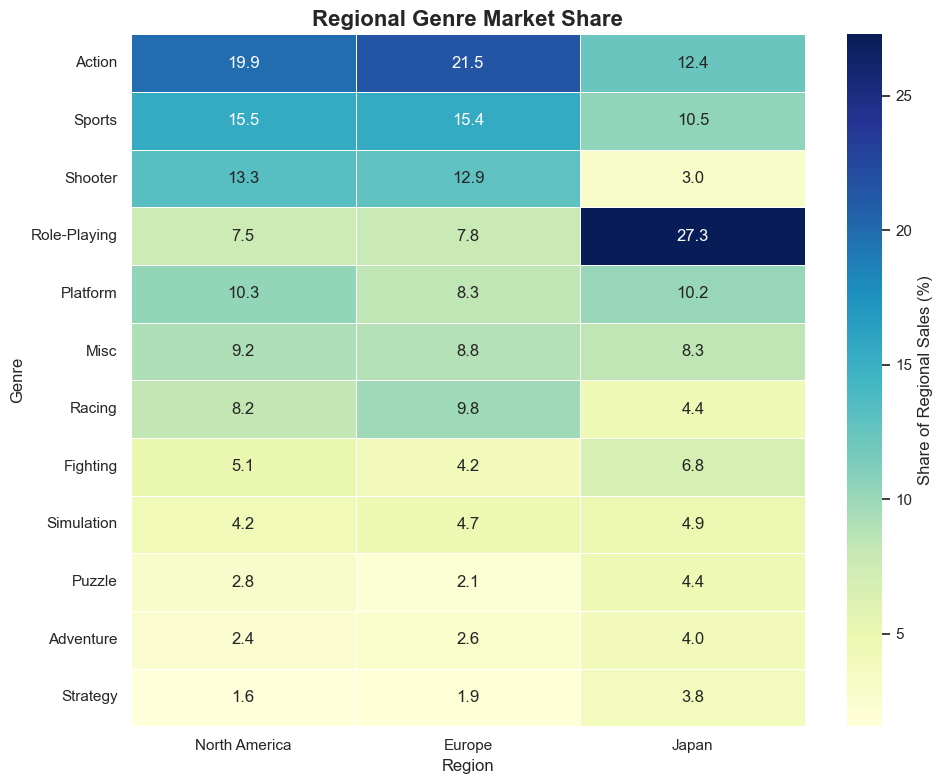

In [27]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    market_share_heatmap,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu",
    linewidths=0.5,
    cbar_kws={"label": "Share of Regional Sales (%)"}
)

plt.title(
    "Regional Genre Market Share",
    fontsize=16,
    fontweight="bold"
)
plt.xlabel("Region")
plt.ylabel("Genre")
plt.tight_layout()
plt.show()

## 12. Strongest Regional Market for Each Genre

For each genre, the region in which it has the highest market-share percentage is identified.

This does not necessarily mean that the genre sells the most units in that region. Instead, it identifies the region where the genre occupies the largest share of the local market.

In [28]:
# Create a readable table of market-share values
strongest_region = genre_market_share.copy()

strongest_region = strongest_region.rename(
    columns={
        "na_share_pct": "North America",
        "eu_share_pct": "Europe",
        "jp_share_pct": "Japan"
    }
)

# Identify the region with the highest market share for each genre
strongest_region["Strongest Region"] = (
    strongest_region[
        ["North America", "Europe", "Japan"]
    ]
    .idxmax(axis=1)
)

# Record the highest regional market-share value
strongest_region["Highest Market Share (%)"] = (
    strongest_region[
        ["North America", "Europe", "Japan"]
    ]
    .max(axis=1)
)

strongest_region = strongest_region.rename(
    columns={"genre": "Genre"}
)

strongest_region = strongest_region.sort_values(
    "Highest Market Share (%)",
    ascending=False
).reset_index(drop=True)

strongest_region

,Genre,North America,Europe,Japan,Strongest Region,Highest Market Share (%)
0,Role-Playing,7.54,7.79,27.27,Japan,27.27
1,Action,19.91,21.46,12.35,Europe,21.46
2,Sports,15.48,15.43,10.49,North America,15.48
3,Shooter,13.29,12.90,2.97,North America,13.29
4,Platform,10.31,8.34,10.17,North America,10.31
5,Racing,8.25,9.82,4.41,Europe,9.82
6,Misc,9.17,8.80,8.31,North America,9.17
7,Fighting,5.10,4.16,6.79,Japan,6.79
8,Simulation,4.19,4.70,4.95,Japan,4.95
9,Puzzle,2.82,2.10,4.41,Japan,4.41


## 13. Regional Specialization

A regional specialization score is calculated to measure how differently a genre performs across the three markets.

The score is defined as the difference between the genre's highest and lowest regional market-share percentages.

A larger score indicates that the genre's popularity varies substantially between regions. A smaller score indicates that the genre holds a more similar market position across North America, Europe, and Japan.

In [29]:
regional_specialization = strongest_region.copy()

# Calculate the range between the highest and lowest market shares
regional_specialization["Specialization Score"] = (
    regional_specialization[
        ["North America", "Europe", "Japan"]
    ].max(axis=1)
    -
    regional_specialization[
        ["North America", "Europe", "Japan"]
    ].min(axis=1)
)

regional_specialization = regional_specialization[
    [
        "Genre",
        "North America",
        "Europe",
        "Japan",
        "Strongest Region",
        "Specialization Score"
    ]
]

regional_specialization = regional_specialization.sort_values(
    "Specialization Score",
    ascending=False
).reset_index(drop=True)

regional_specialization

,Genre,North America,Europe,Japan,Strongest Region,Specialization Score
0,Role-Playing,7.54,7.79,27.27,Japan,19.73
1,Shooter,13.29,12.90,2.97,North America,10.32
2,Action,19.91,21.46,12.35,Europe,9.11
3,Racing,8.25,9.82,4.41,Europe,5.41
4,Sports,15.48,15.43,10.49,North America,4.99
5,Fighting,5.10,4.16,6.79,Japan,2.63
6,Puzzle,2.82,2.10,4.41,Japan,2.31
7,Strategy,1.57,1.86,3.82,Japan,2.26
8,Platform,10.31,8.34,10.17,North America,1.97
9,Adventure,2.36,2.65,4.05,Japan,1.69


## 14. Most Regionally Specialized Genres

The genres with the largest specialization scores show the greatest differences in relative popularity across the three markets.

In [30]:
# Select the five genres with the largest regional differences
most_specialized_genres = regional_specialization.head(5)

most_specialized_genres

,Genre,North America,Europe,Japan,Strongest Region,Specialization Score
0,Role-Playing,7.54,7.79,27.27,Japan,19.73
1,Shooter,13.29,12.90,2.97,North America,10.32
2,Action,19.91,21.46,12.35,Europe,9.11
3,Racing,8.25,9.82,4.41,Europe,5.41
4,Sports,15.48,15.43,10.49,North America,4.99


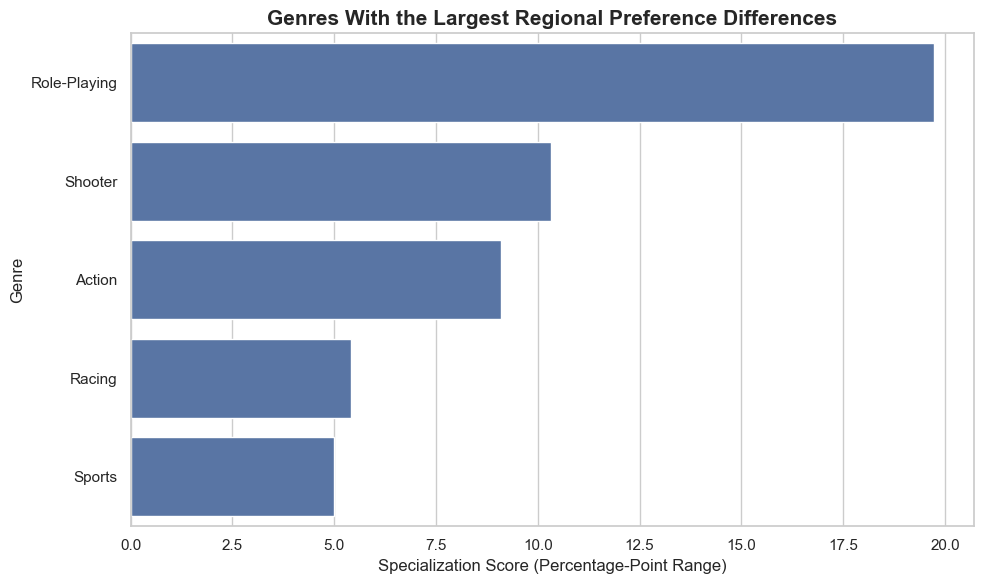

In [31]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=most_specialized_genres,
    x="Specialization Score",
    y="Genre"
)

plt.title(
    "Genres With the Largest Regional Preference Differences",
    fontsize=15,
    fontweight="bold"
)
plt.xlabel("Specialization Score (Percentage-Point Range)")
plt.ylabel("Genre")
plt.tight_layout()
plt.show()

## 15. Most Internationally Consistent Genres

Genres with the smallest specialization scores have the most similar market-share percentages across North America, Europe, and Japan.

In [32]:
# Select the five genres with the smallest regional differences
most_consistent_genres = (
    regional_specialization
    .sort_values("Specialization Score")
    .head(5)
    .reset_index(drop=True)
)

most_consistent_genres

,Genre,North America,Europe,Japan,Strongest Region,Specialization Score
0,Simulation,4.19,4.70,4.95,Japan,0.75
1,Misc,9.17,8.80,8.31,North America,0.87
2,Adventure,2.36,2.65,4.05,Japan,1.69
3,Platform,10.31,8.34,10.17,North America,1.97
4,Strategy,1.57,1.86,3.82,Japan,2.26


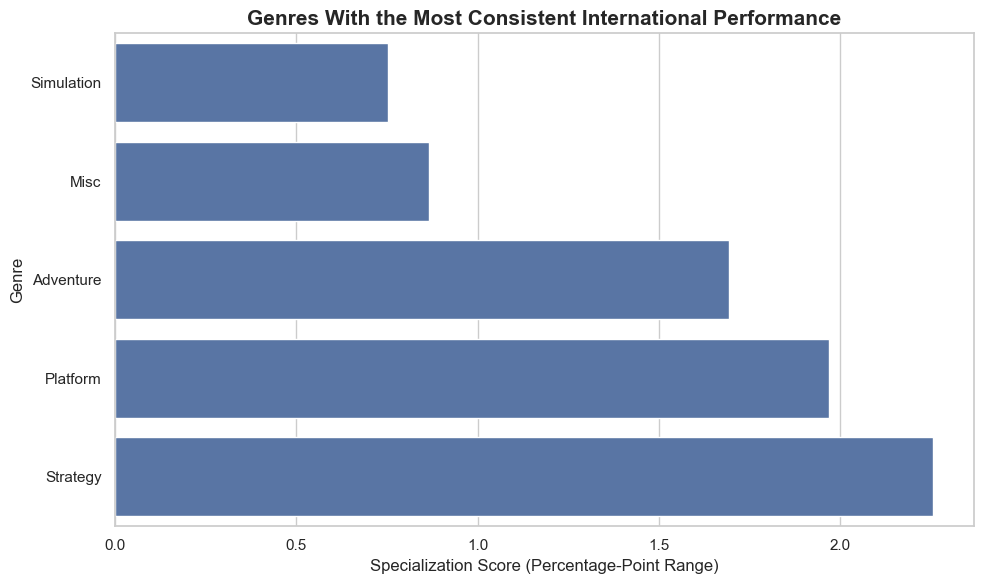

In [33]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=most_consistent_genres,
    x="Specialization Score",
    y="Genre"
)

plt.title(
    "Genres With the Most Consistent International Performance",
    fontsize=15,
    fontweight="bold"
)
plt.xlabel("Specialization Score (Percentage-Point Range)")
plt.ylabel("Genre")
plt.tight_layout()
plt.show()

## 16. Similarity Between Regional Genre Preferences

Correlation is used to compare the genre market-share profiles of North America, Europe, and Japan.

A correlation closer to 1 indicates that two regions rank and distribute genre popularity similarly. A lower correlation indicates greater differences in genre preferences.

In [34]:
# Calculate correlations between regional genre market-share profiles
regional_preference_correlation = (
    market_share_heatmap.corr()
)

regional_preference_correlation

,North America,Europe,Japan
North America,1.00,0.99,0.29
Europe,0.99,1.00,0.28
Japan,0.29,0.28,1.00


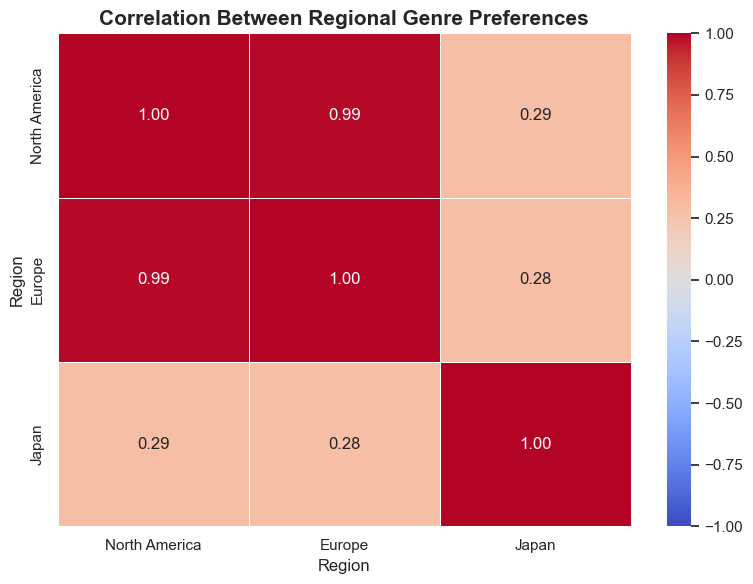

In [35]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    regional_preference_correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5
)

plt.title(
    "Correlation Between Regional Genre Preferences",
    fontsize=15,
    fontweight="bold"
)
plt.xlabel("Region")
plt.ylabel("Region")
plt.tight_layout()
plt.show()

## 17. Pairwise Regional Market-Share Differences

The absolute percentage-point difference between each pair of regions is calculated for every genre.

This makes it possible to identify which specific genres create the largest differences between North America, Europe, and Japan.

In [36]:
pairwise_differences = genre_market_share.copy()

pairwise_differences["NA vs Europe Difference"] = (
    pairwise_differences["na_share_pct"]
    - pairwise_differences["eu_share_pct"]
).abs()

pairwise_differences["NA vs Japan Difference"] = (
    pairwise_differences["na_share_pct"]
    - pairwise_differences["jp_share_pct"]
).abs()

pairwise_differences["Europe vs Japan Difference"] = (
    pairwise_differences["eu_share_pct"]
    - pairwise_differences["jp_share_pct"]
).abs()

pairwise_differences = pairwise_differences[
    [
        "genre",
        "NA vs Europe Difference",
        "NA vs Japan Difference",
        "Europe vs Japan Difference"
    ]
].rename(
    columns={"genre": "Genre"}
)

pairwise_differences

,Genre,NA vs Europe Difference,NA vs Japan Difference,Europe vs Japan Difference
0,Action,1.55,7.56,9.11
1,Sports,0.06,4.99,4.94
2,Shooter,0.39,10.32,9.93
3,Role-Playing,0.25,19.73,19.48
4,Platform,1.97,0.13,1.84
5,Misc,0.37,0.87,0.49
6,Racing,1.57,3.84,5.41
7,Fighting,0.95,1.69,2.63
8,Simulation,0.50,0.75,0.25
9,Puzzle,0.72,1.59,2.31


In [37]:
na_eu_differences = (
    pairwise_differences[
        ["Genre", "NA vs Europe Difference"]
    ]
    .sort_values(
        "NA vs Europe Difference",
        ascending=False
    )
    .head(5)
    .reset_index(drop=True)
)

na_eu_differences

,Genre,NA vs Europe Difference
0,Platform,1.97
1,Racing,1.57
2,Action,1.55
3,Fighting,0.95
4,Puzzle,0.72


In [38]:
na_jp_differences = (
    pairwise_differences[
        ["Genre", "NA vs Japan Difference"]
    ]
    .sort_values(
        "NA vs Japan Difference",
        ascending=False
    )
    .head(5)
    .reset_index(drop=True)
)

na_jp_differences

,Genre,NA vs Japan Difference
0,Role-Playing,19.73
1,Shooter,10.32
2,Action,7.56
3,Sports,4.99
4,Racing,3.84


In [39]:
eu_jp_differences = (
    pairwise_differences[
        ["Genre", "Europe vs Japan Difference"]
    ]
    .sort_values(
        "Europe vs Japan Difference",
        ascending=False
    )
    .head(5)
    .reset_index(drop=True)
)

eu_jp_differences

,Genre,Europe vs Japan Difference
0,Role-Playing,19.48
1,Shooter,9.93
2,Action,9.11
3,Racing,5.41
4,Sports,4.94


## 18. Number of Games Released by Genre

Total sales may partly reflect the number of recorded releases within each genre.

To add context, the number of recorded releases in each genre is compared with total regional sales.

In [40]:
# Count the number of games in each genre
genre_game_counts = (
    df.groupby("genre")
    .size()
    .reset_index(name="game_count")
)

genre_game_counts = genre_game_counts.sort_values(
    "game_count",
    ascending=False
).reset_index(drop=True)

genre_game_counts

,genre,game_count
0,Action,3250
1,Sports,2304
2,Misc,1686
3,Role-Playing,1468
4,Shooter,1282
5,Adventure,1274
6,Racing,1225
7,Platform,875
8,Simulation,847
9,Fighting,836


In [41]:
genre_sales_and_counts = genre_regional_sales.merge(
    genre_game_counts,
    on="genre",
    how="left"
)

genre_sales_and_counts

,genre,na_sales,eu_sales,jp_sales,combined_regional_sales,game_count
0,Action,861.77,516.48,158.64,"1,536.89",3250
1,Sports,670.09,371.34,134.76,"1,176.19",2304
2,Shooter,575.16,310.45,38.18,923.79,1282
3,Role-Playing,326.50,187.57,350.25,864.32,1468
4,Platform,445.99,200.65,130.65,777.29,875
5,Misc,396.92,211.77,106.67,715.36,1686
6,Racing,356.93,236.31,56.61,649.85,1225
7,Fighting,220.74,100.00,87.15,407.89,836
8,Simulation,181.51,113.02,63.54,358.07,847
9,Puzzle,122.01,50.52,56.68,229.21,570


## 19. Average Regional Sales per Game

Average sales per recorded release are calculated to distinguish between genres that generate high total sales because they contain many releases and genres whose individual releases tend to perform strongly.

These values are descriptive averages and may be influenced by a small number of highly successful games.

In [42]:
genre_sales_and_counts["avg_na_sales_per_game"] = (
    genre_sales_and_counts["na_sales"]
    / genre_sales_and_counts["game_count"]
)

genre_sales_and_counts["avg_eu_sales_per_game"] = (
    genre_sales_and_counts["eu_sales"]
    / genre_sales_and_counts["game_count"]
)

genre_sales_and_counts["avg_jp_sales_per_game"] = (
    genre_sales_and_counts["jp_sales"]
    / genre_sales_and_counts["game_count"]
)

average_regional_sales = genre_sales_and_counts[
    [
        "genre",
        "game_count",
        "avg_na_sales_per_game",
        "avg_eu_sales_per_game",
        "avg_jp_sales_per_game"
    ]
].sort_values(
    "avg_na_sales_per_game",
    ascending=False
).reset_index(drop=True)

average_regional_sales

,genre,game_count,avg_na_sales_per_game,avg_eu_sales_per_game,avg_jp_sales_per_game
0,Platform,875,0.51,0.23,0.15
1,Shooter,1282,0.45,0.24,0.03
2,Racing,1225,0.29,0.19,0.05
3,Sports,2304,0.29,0.16,0.06
4,Action,3250,0.27,0.16,0.05
5,Fighting,836,0.26,0.12,0.10
6,Misc,1686,0.24,0.13,0.06
7,Role-Playing,1468,0.22,0.13,0.24
8,Simulation,847,0.21,0.13,0.08
9,Puzzle,570,0.21,0.09,0.10


## 20. Average Sales per Game by Genre and Region

The heatmap compares the average sales generated per recorded release in each genre and regional market.

In [43]:
average_sales_heatmap = (
    average_regional_sales
    .set_index("genre")[
        [
            "avg_na_sales_per_game",
            "avg_eu_sales_per_game",
            "avg_jp_sales_per_game"
        ]
    ]
)

average_sales_heatmap.columns = [
    "North America",
    "Europe",
    "Japan"
]

average_sales_heatmap

,North America,Europe,Japan
genre,,,
Platform,0.51,0.23,0.15
Shooter,0.45,0.24,0.03
Racing,0.29,0.19,0.05
Sports,0.29,0.16,0.06
Action,0.27,0.16,0.05
Fighting,0.26,0.12,0.10
Misc,0.24,0.13,0.06
Role-Playing,0.22,0.13,0.24
Simulation,0.21,0.13,0.08


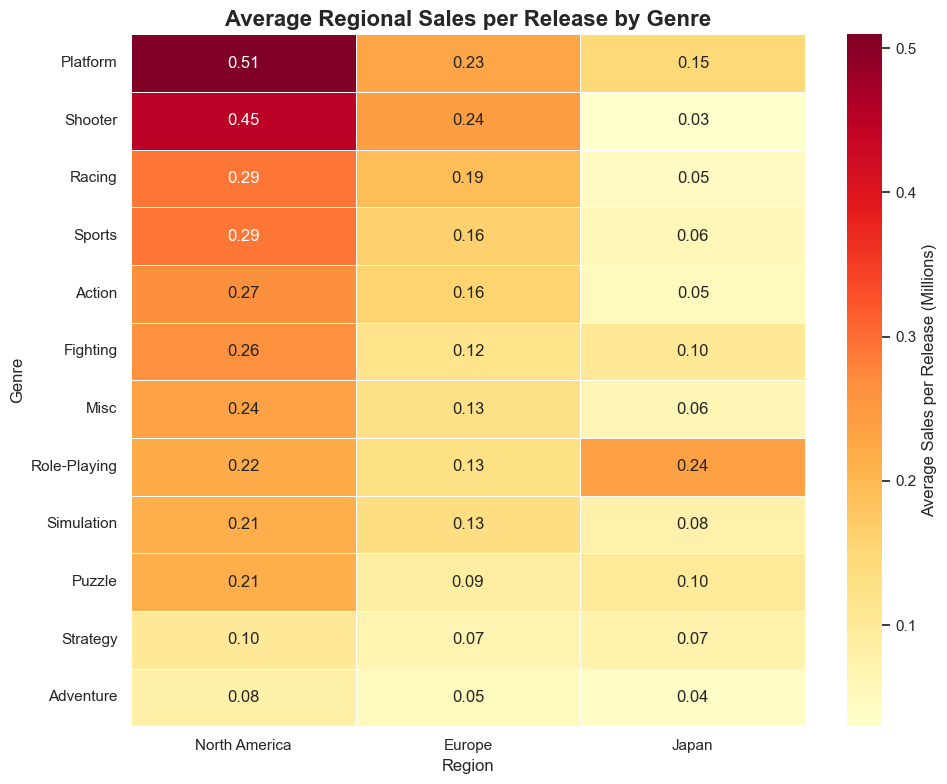

In [44]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    average_sales_heatmap,
    annot=True,
    fmt=".2f",
    cmap="YlOrRd",
    linewidths=0.5,
    cbar_kws={"label": "Average Sales per Release (Millions)"}
)

plt.title(
    "Average Regional Sales per Release by Genre",
    fontsize=16,
    fontweight="bold"
)
plt.xlabel("Region")
plt.ylabel("Genre")
plt.tight_layout()
plt.show()

## 21. Consolidated Regional Results

The final table combines the most important measurements used in the regional analysis:

- total regional sales
- regional market shares
- regional rankings
- strongest regional market
- specialization score
- number of games

In [45]:
final_regional_results = (
    genre_regional_sales
    .merge(
        genre_market_share,
        on="genre",
        how="left"
    )
    .merge(
        regional_rankings[
            ["genre", "na_rank", "eu_rank", "jp_rank"]
        ],
        on="genre",
        how="left"
    )
    .merge(
        regional_specialization[
            ["Genre", "Strongest Region", "Specialization Score"]
        ].rename(columns={"Genre": "genre"}),
        on="genre",
        how="left"
    )
    .merge(
        genre_game_counts,
        on="genre",
        how="left"
    )
)

final_regional_results = final_regional_results[
    [
        "genre",
        "game_count",
        "na_sales",
        "na_share_pct",
        "na_rank",
        "eu_sales",
        "eu_share_pct",
        "eu_rank",
        "jp_sales",
        "jp_share_pct",
        "jp_rank",
        "combined_regional_sales",
        "Strongest Region",
        "Specialization Score"
    ]
]

final_regional_results = final_regional_results.sort_values(
    "combined_regional_sales",
    ascending=False
).reset_index(drop=True)

final_regional_results

,genre,game_count,na_sales,na_share_pct,na_rank,eu_sales,eu_share_pct,eu_rank,jp_sales,jp_share_pct,jp_rank,combined_regional_sales,Strongest Region,Specialization Score
0,Action,3250,861.77,19.91,1,516.48,21.46,1,158.64,12.35,2,"1,536.89",Europe,9.11
1,Sports,2304,670.09,15.48,2,371.34,15.43,2,134.76,10.49,3,"1,176.19",North America,4.99
2,Shooter,1282,575.16,13.29,3,310.45,12.90,3,38.18,2.97,12,923.79,North America,10.32
3,Role-Playing,1468,326.50,7.54,7,187.57,7.79,7,350.25,27.27,1,864.32,Japan,19.73
4,Platform,875,445.99,10.31,4,200.65,8.34,6,130.65,10.17,4,777.29,North America,1.97
5,Misc,1686,396.92,9.17,5,211.77,8.80,5,106.67,8.31,5,715.36,North America,0.87
6,Racing,1225,356.93,8.25,6,236.31,9.82,4,56.61,4.41,9,649.85,Europe,5.41
7,Fighting,836,220.74,5.10,8,100.00,4.16,9,87.15,6.79,6,407.89,Japan,2.63
8,Simulation,847,181.51,4.19,9,113.02,4.70,8,63.54,4.95,7,358.07,Japan,0.75
9,Puzzle,570,122.01,2.82,10,50.52,2.10,11,56.68,4.41,8,229.21,Japan,2.31


In [46]:
final_regional_results_display = final_regional_results.rename(
    columns={
        "genre": "Genre",
        "game_count": "Number of Games",
        "na_sales": "North America Sales",
        "na_share_pct": "North America Share (%)",
        "na_rank": "North America Rank",
        "eu_sales": "Europe Sales",
        "eu_share_pct": "Europe Share (%)",
        "eu_rank": "Europe Rank",
        "jp_sales": "Japan Sales",
        "jp_share_pct": "Japan Share (%)",
        "jp_rank": "Japan Rank",
        "combined_regional_sales": "Combined Regional Sales"
    }
)

final_regional_results_display

,Genre,Number of Games,North America Sales,North America Share (%),North America Rank,Europe Sales,Europe Share (%),Europe Rank,Japan Sales,Japan Share (%),Japan Rank,Combined Regional Sales,Strongest Region,Specialization Score
0,Action,3250,861.77,19.91,1,516.48,21.46,1,158.64,12.35,2,"1,536.89",Europe,9.11
1,Sports,2304,670.09,15.48,2,371.34,15.43,2,134.76,10.49,3,"1,176.19",North America,4.99
2,Shooter,1282,575.16,13.29,3,310.45,12.90,3,38.18,2.97,12,923.79,North America,10.32
3,Role-Playing,1468,326.50,7.54,7,187.57,7.79,7,350.25,27.27,1,864.32,Japan,19.73
4,Platform,875,445.99,10.31,4,200.65,8.34,6,130.65,10.17,4,777.29,North America,1.97
5,Misc,1686,396.92,9.17,5,211.77,8.80,5,106.67,8.31,5,715.36,North America,0.87
6,Racing,1225,356.93,8.25,6,236.31,9.82,4,56.61,4.41,9,649.85,Europe,5.41
7,Fighting,836,220.74,5.10,8,100.00,4.16,9,87.15,6.79,6,407.89,Japan,2.63
8,Simulation,847,181.51,4.19,9,113.02,4.70,8,63.54,4.95,7,358.07,Japan,0.75
9,Puzzle,570,122.01,2.82,10,50.52,2.10,11,56.68,4.41,8,229.21,Japan,2.31
